# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif, chi2, SelectFromModel
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train (1).csv")
df_test = pd.read_csv("test (1).csv")

# 2. EDA (Exploratory Data Analysis)

## 2.1 General

In [3]:
print(f"|{'# of Null in Train':>20}|")
print(f"{df.isnull().sum()}|")

|  # of Null in Train|
ID                    0
Edad                  0
Tipo_Trabajo          0
Estado_Civil          0
Educacion             0
Incumplimiento        0
Vivienda              0
Consumo               0
Contacto              0
Mes                   0
Dias                  0
Campana               0
Dias_Ultima_Camp      0
No_Contactos          0
Resultado_Anterior    0
emp_var_rate          0
cons_price_idx        0
cons_conf_idx         0
euribor3m             0
nr_employed           0
y                     0
dtype: int64|


In [4]:
print("Types of variables in Train:")
print(df.dtypes)

Types of variables in Train:
ID                      int64
Edad                    int64
Tipo_Trabajo              str
Estado_Civil              str
Educacion                 str
Incumplimiento            str
Vivienda                  str
Consumo                   str
Contacto                  str
Mes                       str
Dias                      str
Campana                 int64
Dias_Ultima_Camp        int64
No_Contactos            int64
Resultado_Anterior        str
emp_var_rate          float64
cons_price_idx        float64
cons_conf_idx         float64
euribor3m             float64
nr_employed           float64
y                       int64
dtype: object


## 2.2 Histograms

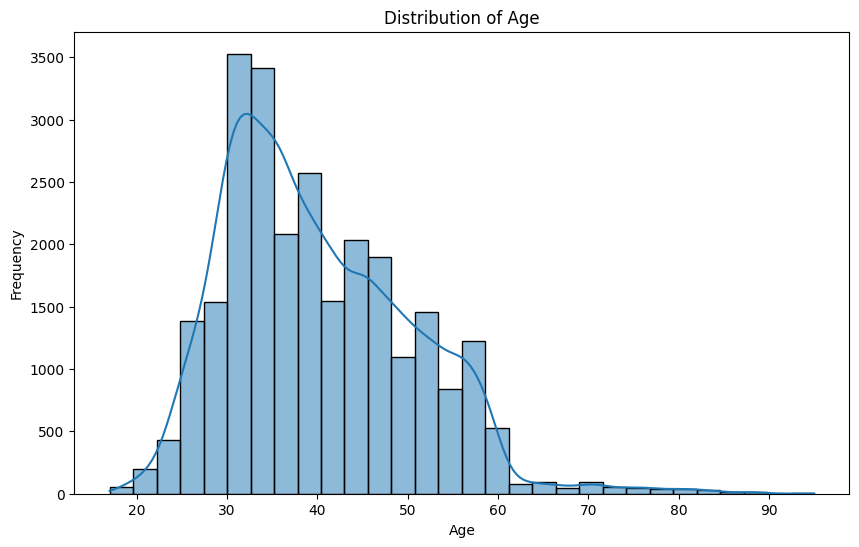

In [5]:
# Distribution of Age variable
plt.figure(figsize=(10, 6))
sns.histplot(df["Edad"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

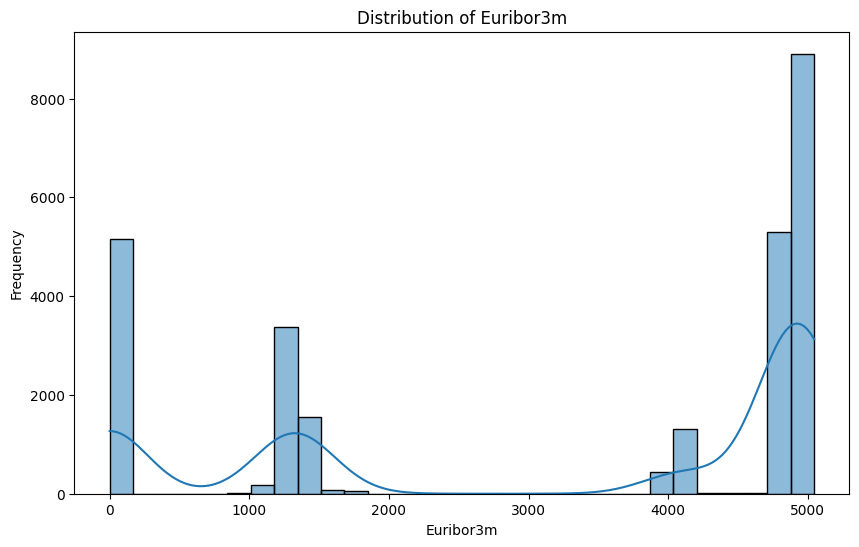

In [6]:
# Distribution of euribor3m variable
plt.figure(figsize=(10, 6))
sns.histplot(df["euribor3m"], bins=30, kde=True)
plt.title("Distribution of Euribor3m")
plt.xlabel("Euribor3m")
plt.ylabel("Frequency")
plt.show()

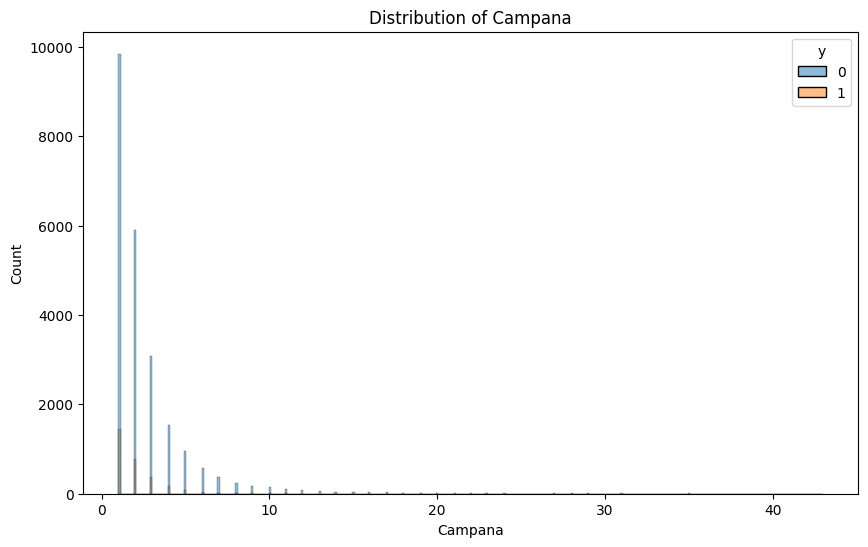

In [7]:
# Histogram of Campana variable
plt.figure(figsize=(10, 6))
sns.histplot(x="Campana", data=df, hue="y")
plt.title("Distribution of Campana")
plt.xlabel("Campana")
plt.ylabel("Count")
plt.show()

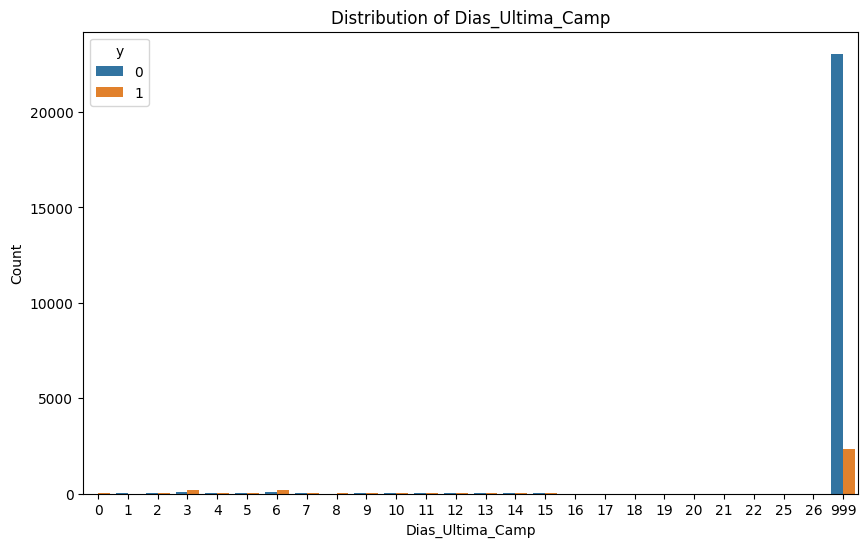

In [8]:
# Histogram of Dias_Ultima_Camp variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Dias_Ultima_Camp", data=df, hue="y")
plt.title("Distribution of Dias_Ultima_Camp")
plt.xlabel("Dias_Ultima_Camp")
plt.ylabel("Count")
plt.show()

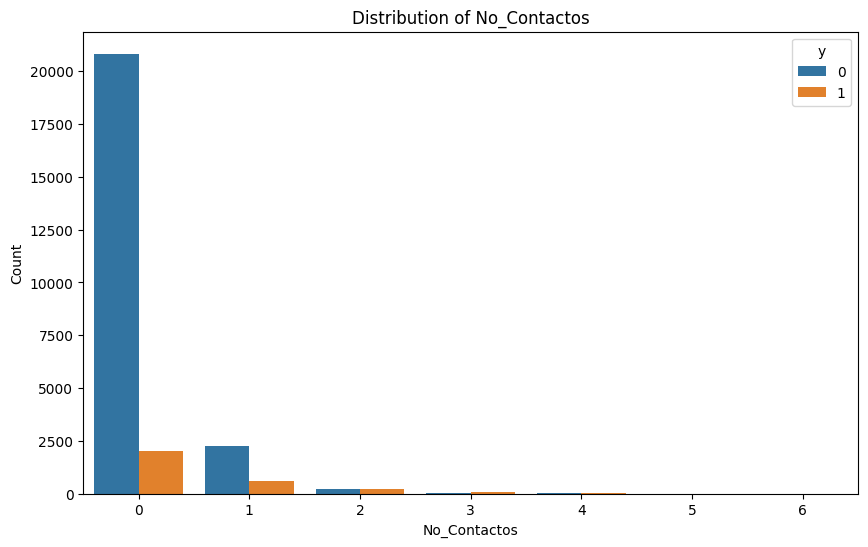

In [9]:
# Histogram of No_Contactos variable
plt.figure(figsize=(10, 6))
sns.countplot(x="No_Contactos", data=df, hue="y")
plt.title("Distribution of No_Contactos")
plt.xlabel("No_Contactos")
plt.ylabel("Count")
plt.show()

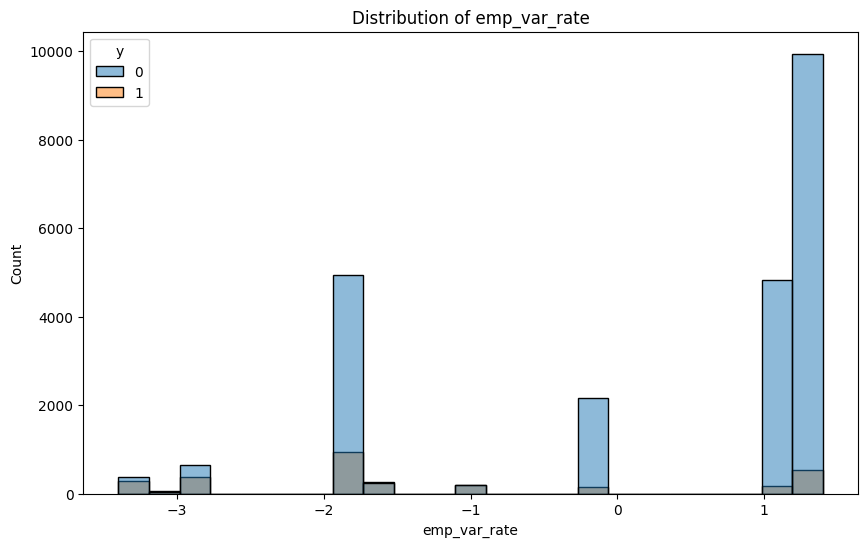

In [10]:
# Histogram of emp_var_rate variable
plt.figure(figsize=(10, 6))
sns.histplot(x="emp_var_rate", data=df, hue="y")
plt.title("Distribution of emp_var_rate")
plt.xlabel("emp_var_rate")
plt.ylabel("Count")
plt.show()

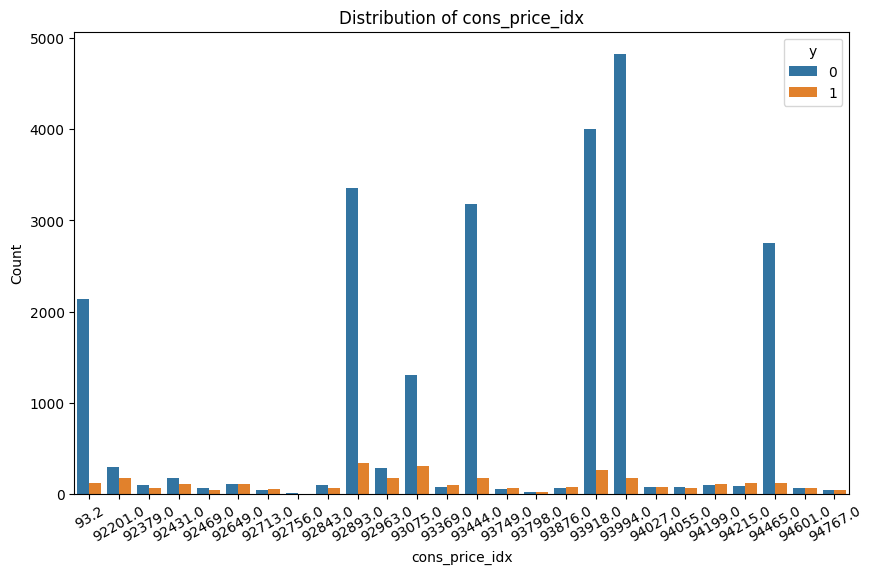

In [11]:
# Histogram of cons_price_idx variable
plt.figure(figsize=(10, 6))
sns.countplot(x="cons_price_idx", data=df, hue="y")
plt.title("Distribution of cons_price_idx")
plt.xticks(rotation=30)
plt.xlabel("cons_price_idx")
plt.ylabel("Count")
plt.show()

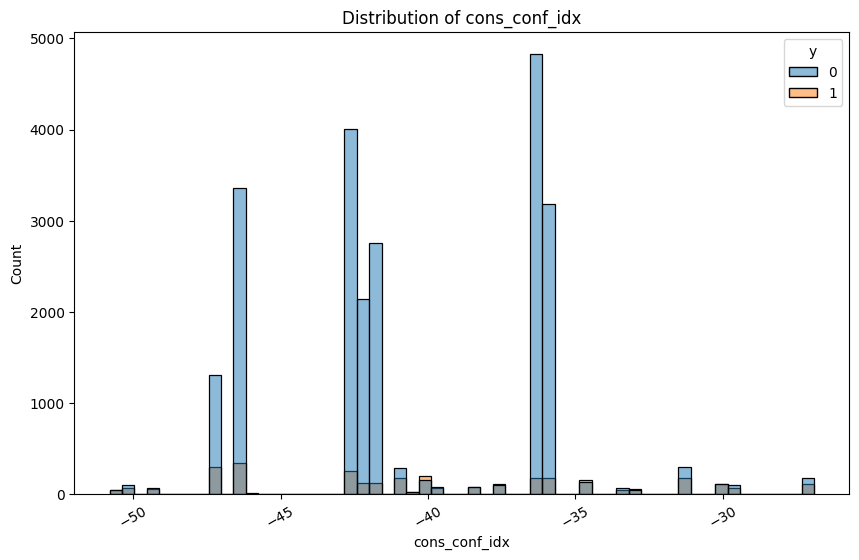

In [12]:
# Histogram of cons_conf_idx variable
plt.figure(figsize=(10, 6))
sns.histplot(x="cons_conf_idx", data=df, hue="y")
plt.title("Distribution of cons_conf_idx")
plt.xticks(rotation=30)
plt.xlabel("cons_conf_idx")
plt.ylabel("Count")
plt.show()

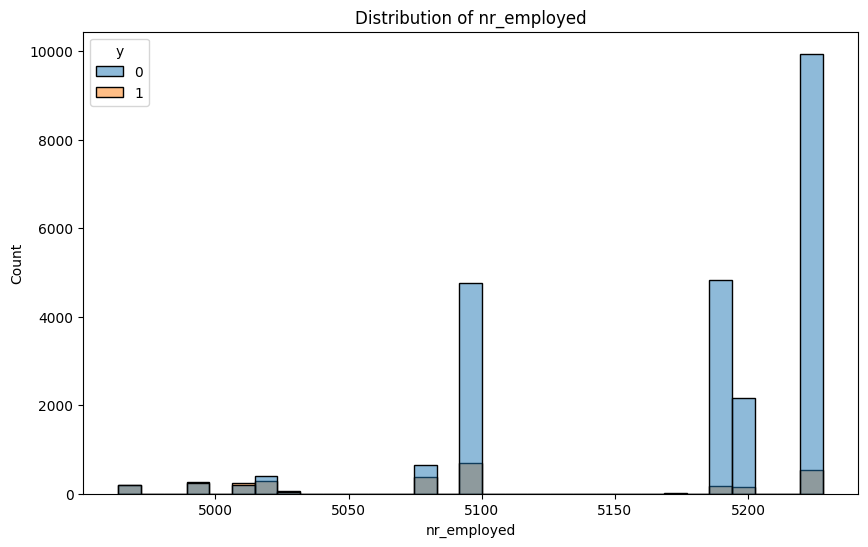

In [13]:
# Histogram of nr_employed variable
plt.figure(figsize=(10, 6))
sns.histplot(x="nr_employed", data=df, hue="y")
plt.title("Distribution of nr_employed")
plt.xlabel("nr_employed")
plt.ylabel("Count")
plt.show()

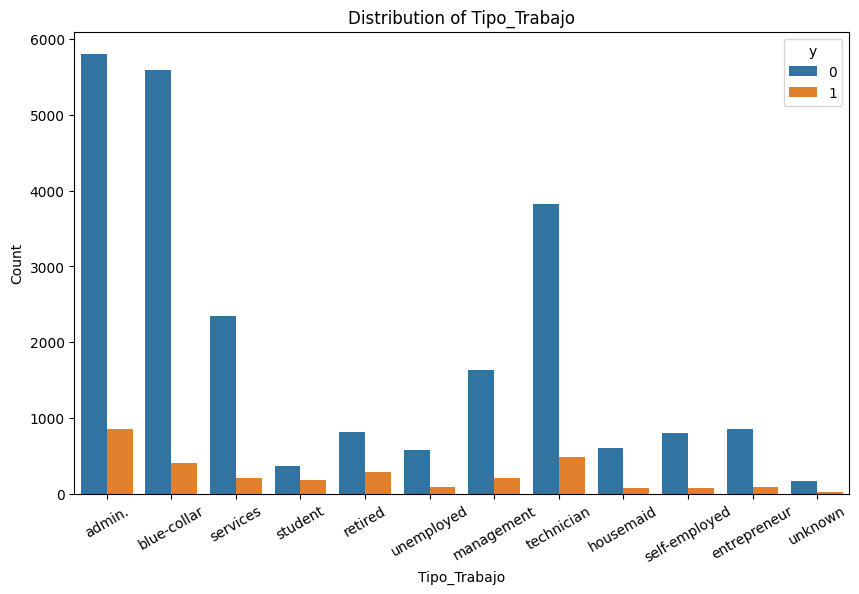

In [14]:
# Histogram of Tipo_Trabajo variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Tipo_Trabajo", data=df, hue="y")
plt.title("Distribution of Tipo_Trabajo")
plt.xticks(rotation=30)
plt.xlabel("Tipo_Trabajo")
plt.ylabel("Count")
plt.show()

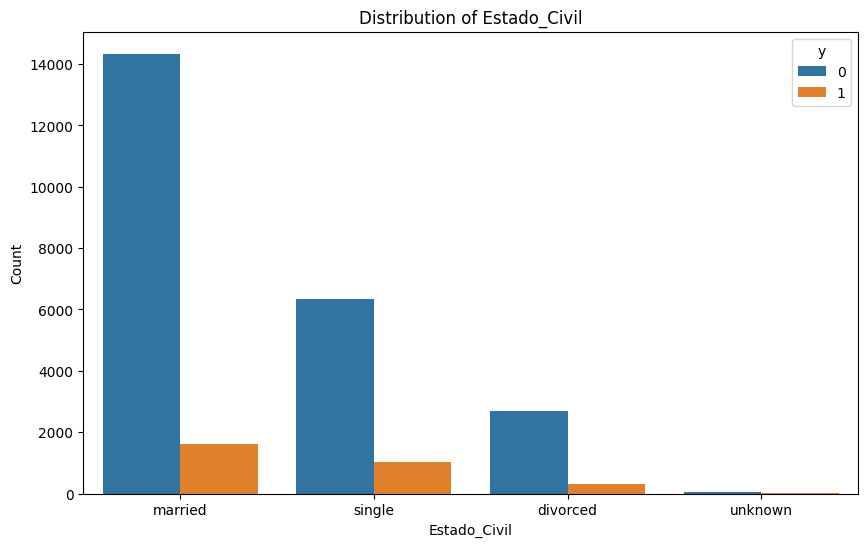

In [15]:
# Histogram of Estado_Civil variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Estado_Civil", data=df, hue="y")
plt.title("Distribution of Estado_Civil")
plt.xlabel("Estado_Civil")
plt.ylabel("Count")
plt.show()

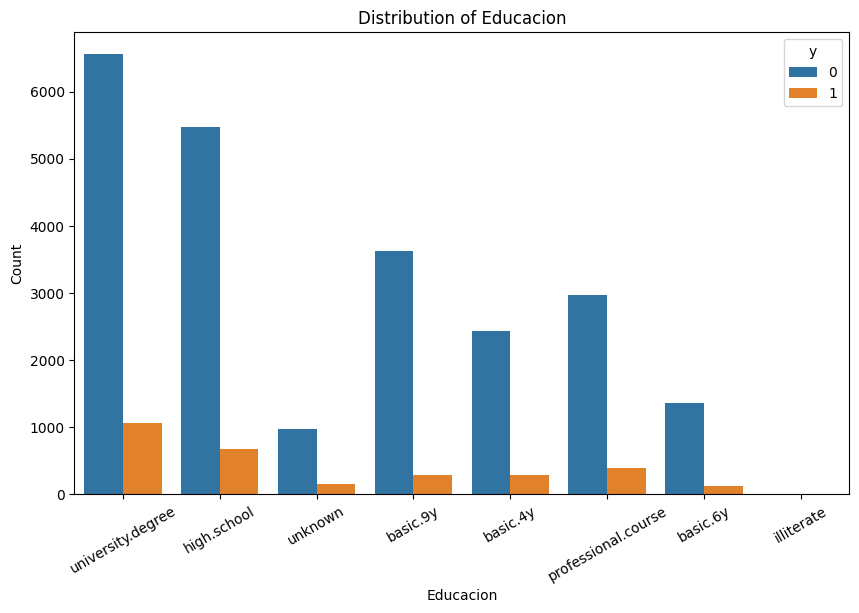

In [16]:
# Histogram of Educacion variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Educacion", data=df, hue="y")
plt.title("Distribution of Educacion")
plt.xticks(rotation=30)
plt.xlabel("Educacion")
plt.ylabel("Count")
plt.show()

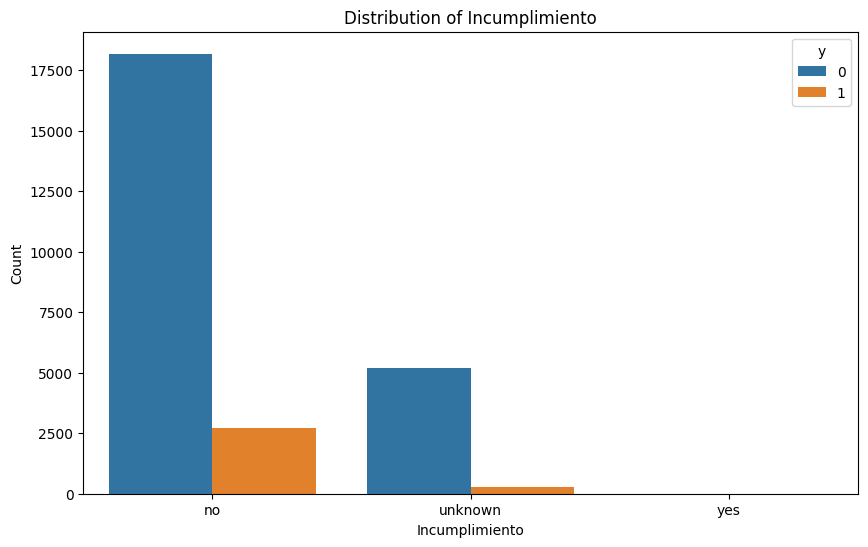

In [17]:
# Histogram of Incumplimiento variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Incumplimiento", data=df, hue="y")
plt.title("Distribution of Incumplimiento")
plt.xlabel("Incumplimiento")
plt.ylabel("Count")
plt.show()

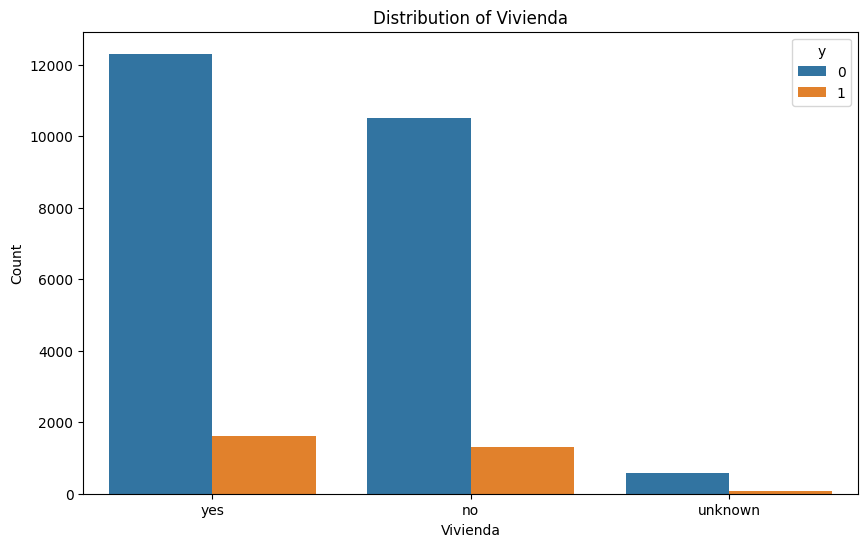

In [18]:
# Histogram of Vivienda variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Vivienda", data=df, hue="y")
plt.title("Distribution of Vivienda")
plt.xlabel("Vivienda")
plt.ylabel("Count")
plt.show()

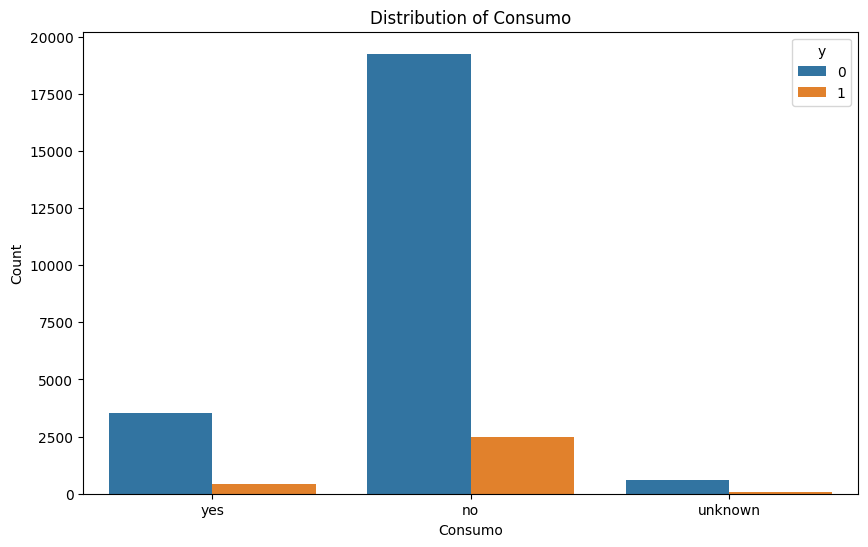

In [19]:
# Histogram of Consumo variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Consumo", data=df, hue="y")
plt.title("Distribution of Consumo")
plt.xlabel("Consumo")
plt.ylabel("Count")
plt.show()

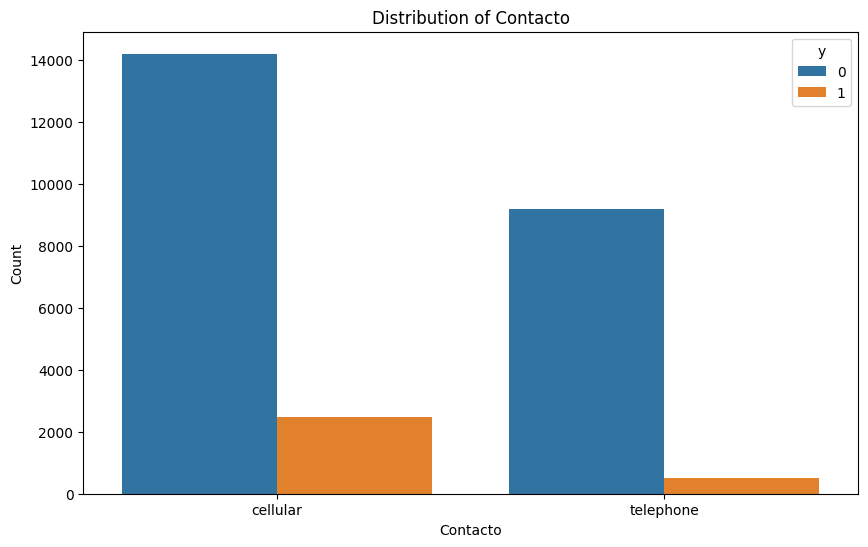

In [20]:
# Histogram of Contacto variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Contacto", data=df, hue="y")
plt.title("Distribution of Contacto")
plt.xlabel("Contacto")
plt.ylabel("Count")
plt.show()

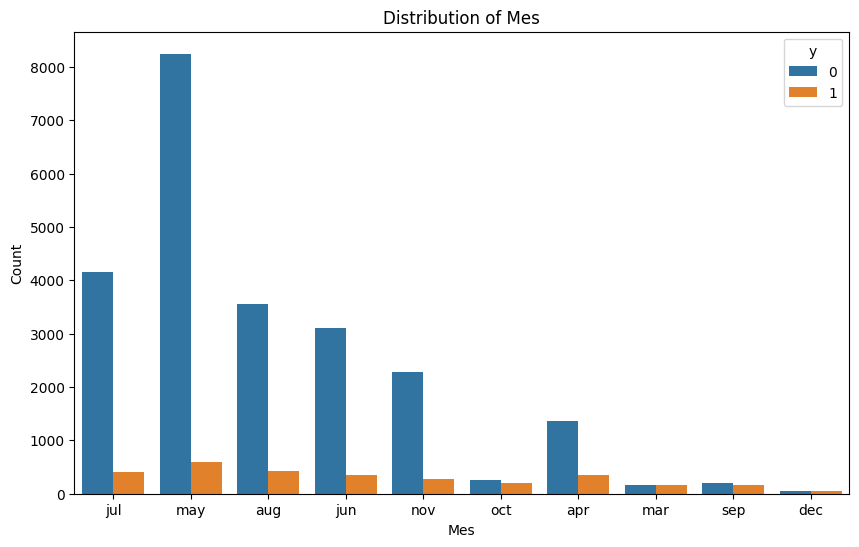

In [21]:
# Histogram of Mes variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Mes", data=df, hue="y")
plt.title("Distribution of Mes")
plt.xlabel("Mes")
plt.ylabel("Count")
plt.show()

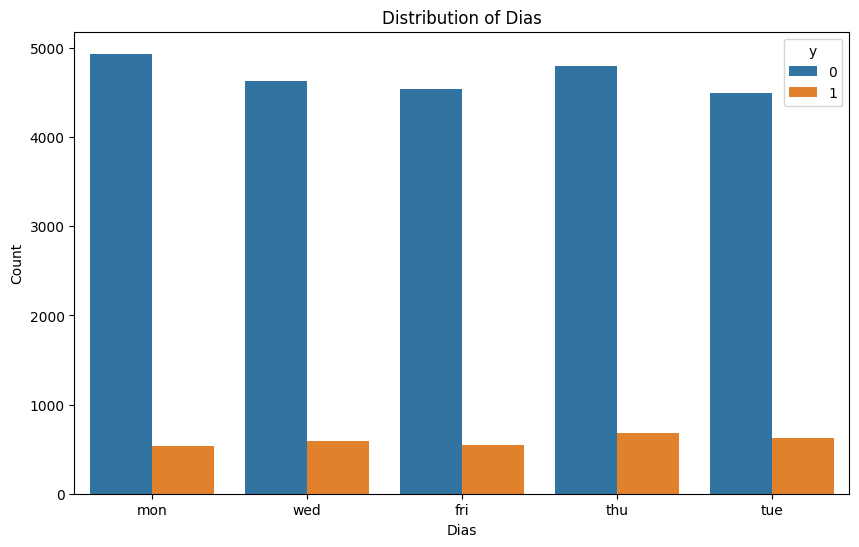

In [22]:
# Histogram of Dias variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Dias", data=df, hue="y")
plt.title("Distribution of Dias")
plt.xlabel("Dias")
plt.ylabel("Count")
plt.show()

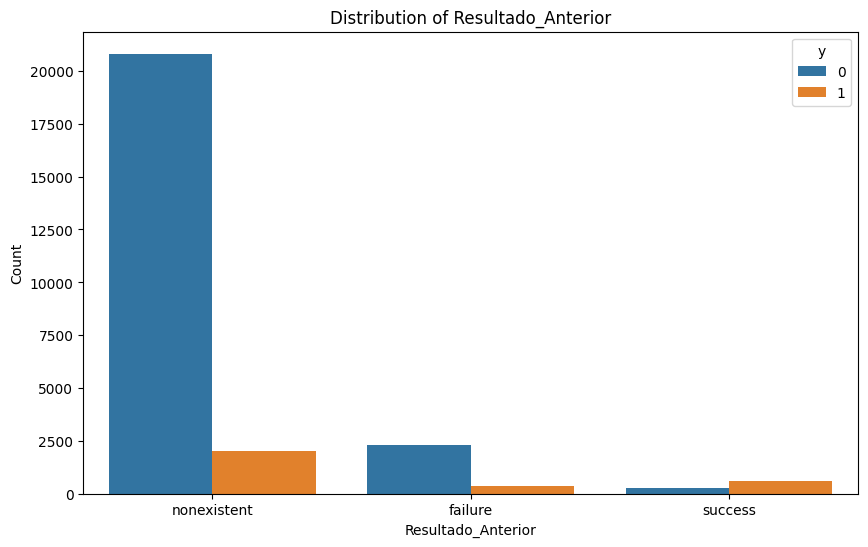

In [23]:
# Histogram of Resultado_Anterior variable
plt.figure(figsize=(10, 6))
sns.countplot(x="Resultado_Anterior", data=df, hue="y")
plt.title("Distribution of Resultado_Anterior")
plt.xlabel("Resultado_Anterior")
plt.ylabel("Count")
plt.show()

# 3. Feature Engineering

## 3.1 One-Hot Encoding

In [24]:
def one_hot_encode(df):
    vars_one_hot = [
        "Tipo_Trabajo",
        "Estado_Civil",
        "Educacion",
        "Incumplimiento",
        "Vivienda",
        "Consumo",
        "Contacto",
        "Resultado_Anterior",
    ]
    new_df = pd.DataFrame()
    for var in vars_one_hot:
        dummies = pd.get_dummies(df[var], prefix=var, drop_first=False, dtype=int)
        new_df = pd.concat([new_df, dummies], axis=1)
    return new_df


new_df = one_hot_encode(df)
print(f"Shape of new dataframe after one-hot encoding: {new_df.shape}")

Shape of new dataframe after one-hot encoding: (26373, 38)


## 3.2 New Variables

In [25]:
def new_vars(df, new_df):
    new_df["price_conf_ratio"] = df["cons_price_idx"] / df["cons_conf_idx"]
    new_df["conf_nr_employed_ratio"] = df["cons_conf_idx"] / df["nr_employed"]
    new_df["price_employed_ratio"] = df["cons_price_idx"] / df["nr_employed"]
    new_df["age_euribor_ratio"] = df["Edad"] / df["euribor3m"]
    new_df["total_num_contacts"] = df["No_Contactos"] + df["Campana"]

    num_cols = [
        "emp_var_rate",
        "cons_price_idx",
        "cons_conf_idx",
        "euribor3m",
        "nr_employed",
    ]
    df_num = df[num_cols]
    new_df = pd.concat([new_df, df_num], axis=1)
    print(
        f"Shape of new dataframe after adding numerical columns and new variables: {new_df.shape}"
    )
    return new_df


new_df = new_vars(df, new_df)
new_df["y"] = df["y"]

Shape of new dataframe after adding numerical columns and new variables: (26373, 48)


## 3.3 Ordinal Encoding

In [26]:
def adjust_mes(df, new_df):
    mes_mapping = {
        "jan": 1,
        "feb": 2,
        "mar": 3,
        "apr": 4,
        "may": 5,
        "jun": 6,
        "jul": 7,
        "aug": 8,
        "sep": 9,
        "oct": 10,
        "nov": 11,
        "dec": 12,
    }
    new_df["Mes"] = df["Mes"].map(mes_mapping)
    return new_df


new_df = adjust_mes(df, new_df)


def adjust_dias(df, new_df):
    dias_mapping = {
        "mon": 1,
        "tue": 2,
        "wed": 3,
        "thu": 4,
        "fri": 5,
    }
    new_df["Dias"] = df["Dias"].map(dias_mapping)
    return new_df


new_df = adjust_dias(df, new_df)
print(f"Shape of new dataframe after adjusting Mes and Dias: {new_df.shape}")

Shape of new dataframe after adjusting Mes and Dias: (26373, 51)


## 3.4 Skewness

In [27]:
def adjust_skewness(df, new_df):
    skewed_cols = [
        "Edad",
        "Campana",
        "Dias_Ultima_Camp",
        "No_Contactos",
        "cons_price_idx",
    ]
    for col in skewed_cols:
        new_df[f"log_{col}"] = np.log1p(df[col])
    return new_df


new_df = adjust_skewness(df, new_df)
print(f"Shape of new dataframe after adjusting skewness: {new_df.shape}")

Shape of new dataframe after adjusting skewness: (26373, 56)


## 3.5 Binning

In [28]:
def bin_data(df, new_df):
    new_df["age_qbin"] = pd.qcut(df["Edad"], q=10, labels=False, duplicates="drop")
    new_df["age_bin"] = pd.cut(df["Edad"], bins=10, labels=False)
    new_df["emp_var_rate_qbin"] = pd.qcut(
        df["emp_var_rate"], q=5, labels=False, duplicates="drop"
    )
    new_df["emp_var_rate_bin"] = pd.cut(df["emp_var_rate"], bins=5, labels=False)
    new_df["cons_conf_idx_qbin"] = pd.qcut(
        df["cons_conf_idx"], q=8, labels=False, duplicates="drop"
    )
    new_df["cons_conf_idx_bin"] = pd.cut(df["cons_conf_idx"], bins=8, labels=False)
    new_df["nr_employed_qbin"] = pd.qcut(
        df["nr_employed"], q=5, labels=False, duplicates="drop"
    )
    new_df["nr_employed_bin"] = pd.cut(df["nr_employed"], bins=5, labels=False)
    new_df["cons_price_idx_bin"] = pd.cut(
        df["cons_price_idx"],
        bins=[0, 91000, 92000, 92500, 93000, 93500, 94000, 94500, 95000],
        labels=False,
    )
    new_df["euribor3m_qbin"] = pd.qcut(
        df["euribor3m"], q=5, labels=False, duplicates="drop"
    )
    new_df["euribor3m_bin"] = pd.cut(df["euribor3m"], bins=5, labels=False)
    return new_df


new_df = bin_data(df, new_df)
print(f"Shape of new dataframe after binning: {new_df.shape}")

Shape of new dataframe after binning: (26373, 67)


# 4. Feature Selection

## 4.1 Correlation (Numerical Variables)

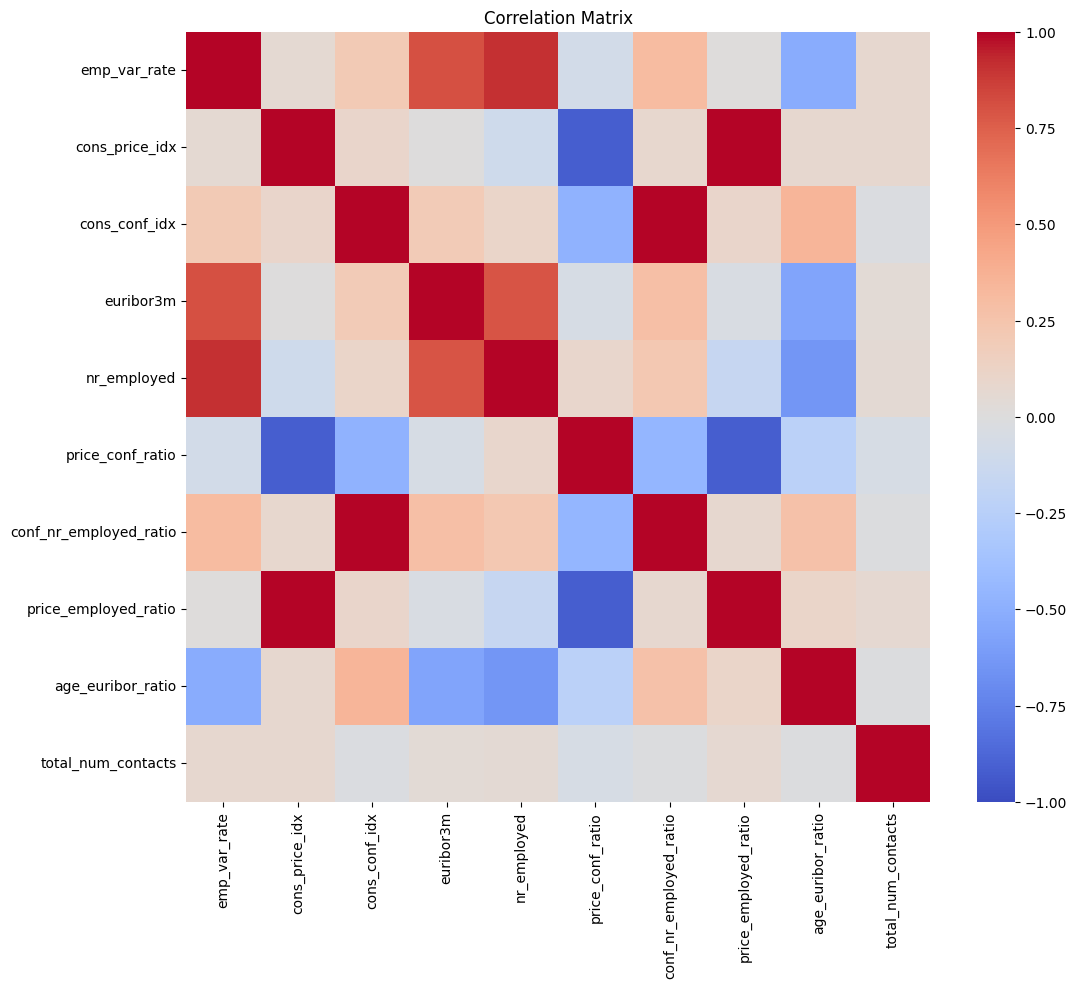

In [29]:
num_cols = [
    "emp_var_rate",
    "cons_price_idx",
    "cons_conf_idx",
    "euribor3m",
    "nr_employed",
    "price_conf_ratio",
    "conf_nr_employed_ratio",
    "price_employed_ratio",
    "age_euribor_ratio",
    "total_num_contacts",
]


def plot_corr(new_df):
    fig = plt.figure(figsize=(12, 10))
    sns.heatmap(new_df[num_cols].corr("pearson"), cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation Matrix")
    plt.show()


plot_corr(new_df)

In [30]:
# Avoid low correlation features
def cols_to_drop(new_df):
    # Avoid high correlation features
    high_corr_pairs = (
        new_df[num_cols].corr().abs().unstack().sort_values(ascending=False)
    )
    high_corr_pairs = high_corr_pairs[high_corr_pairs < 1]
    high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.9]
    to_drop = set()
    for (feat1, feat2), _ in high_corr_pairs.items():
        if feat1 not in to_drop and feat2 not in to_drop:
            if (
                new_df.corrwith(new_df["y"])[feat1]
                > new_df.corrwith(new_df["y"])[feat2]
            ):
                to_drop.add(feat2)
            else:
                to_drop.add(feat1)
    new_df.drop(columns=to_drop, inplace=True)
    print(f"Features dropped due to high correlation: {list(to_drop)}")
    print(f"Shape of dataframe after feature selection: {new_df.shape}")
    return new_df


new_df = cols_to_drop(new_df)

Features dropped due to high correlation: ['cons_price_idx', 'nr_employed', 'price_conf_ratio', 'conf_nr_employed_ratio']
Shape of dataframe after feature selection: (26373, 63)


## 4.2 Correlation (Binary/Frequency Variables)

In [31]:
def corr_chi2(new_df):
    bin_freq_cols = [
        col for col in new_df.columns if col != "y" and col not in num_cols
    ]
    chi2_scores, p_values = chi2(new_df[bin_freq_cols], new_df["y"])
    chi2_results = pd.DataFrame(
        {"Feature": bin_freq_cols, "Chi2_Score": chi2_scores, "P_Value": p_values}
    ).sort_values(by="P_Value", ascending=False)
    chi_2_filter = chi2_results[chi2_results["P_Value"] < 0.05]
    bin_freq_cols_drop = set(chi2_results["Feature"]) - set(chi_2_filter["Feature"])
    new_df.drop(columns=bin_freq_cols_drop, inplace=True)
    print(f"Features dropped due to low chi2 score: {list(bin_freq_cols_drop)}")
    print(f"Shape of dataframe after chi2 feature selection: {new_df.shape}")
    return new_df


new_df = corr_chi2(new_df)

Features dropped due to low chi2 score: ['Vivienda_yes', 'Dias', 'Vivienda_no', 'Incumplimiento_yes', 'Estado_Civil_unknown', 'Vivienda_unknown', 'Consumo_yes', 'Tipo_Trabajo_management', 'Educacion_high.school', 'Tipo_Trabajo_unknown', 'log_Edad', 'Consumo_no', 'Tipo_Trabajo_housemaid', 'Consumo_unknown', 'Educacion_basic.4y', 'Educacion_professional.course', 'Tipo_Trabajo_technician']
Shape of dataframe after chi2 feature selection: (26373, 46)


## 4.3 SelectFromModel

In [32]:
def select_from_model(new_df):
    X = new_df.drop(columns=["y"])
    y = new_df["y"]
    lsvc = LinearSVC(C=0.1, penalty="l1", random_state=42, dual=False).fit(X, y)
    model = SelectFromModel(lsvc, prefit=True)
    mask_cols = model.get_support()
    X_transformed = model.transform(X)
    new_df = pd.DataFrame(X_transformed, columns=X.columns[mask_cols])
    new_df["y"] = y
    print(f"Shape of dataframe after L1 feature selection: {new_df.shape}")
    return new_df


new_df = select_from_model(new_df)

Shape of dataframe after L1 feature selection: (26373, 36)


## 4.4 F_Classifier

In [33]:
def f_classifier(new_df):
    X = new_df.drop(columns=["y"])
    y = new_df["y"]

    f_statistic, p_values = f_classif(X, y)
    f_results = pd.DataFrame(
        {
            "Features": X.columns.tolist(),
            "F-Statistic": f_statistic,
            "P-Values": p_values,
        }
    ).sort_values(by="P-Values", ascending=False)
    f_filter = f_results[f_results["P-Values"] < 0.05]
    cols_f_class_drop = set(f_results["Features"]) - set(f_filter["Features"])
    new_df.drop(columns=cols_f_class_drop, inplace=True)
    print(f"Features dropped due to low f_classifier score: {list(cols_f_class_drop)}")
    print(f"Shape of dataframe after f_classifier feature selection: {new_df.shape}")
    return new_df


new_df = f_classifier(new_df)

Features dropped due to low f_classifier score: ['age_qbin']
Shape of dataframe after f_classifier feature selection: (26373, 35)


In [34]:
def cols_to_maintain(new_df):
    cols = new_df.columns.tolist()
    return cols


final_cols = cols_to_maintain(new_df)

## 4.5 Standard Scaler

In [35]:
def scaler(new_df, final_cols):
    scaler = StandardScaler()
    num_cols = [col for col in final_cols if col != "y"]
    new_df[num_cols] = scaler.fit_transform(new_df[num_cols])
    return new_df


new_df = scaler(new_df, final_cols)

In [36]:
new_df

,Tipo_Trabajo_blue-collar,Tipo_Trabajo_retired,Tipo_Trabajo_self-employed,Tipo_Trabajo_services,Tipo_Trabajo_student,Estado_Civil_divorced,Estado_Civil_married,Educacion_basic.6y,Educacion_basic.9y,Educacion_university.degree,...,emp_var_rate_qbin,emp_var_rate_bin,cons_conf_idx_qbin,cons_conf_idx_bin,nr_employed_qbin,nr_employed_bin,cons_price_idx_bin,euribor3m_qbin,euribor3m_bin,y
0,-0.542920,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,-0.417272,1.568331,...,1.035926,0.757470,-0.714361,-0.573046,1.109051,0.649730,0.575277,0.769027,0.806813,0
1,1.841893,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,-0.417272,-0.637621,...,1.035926,0.757470,-0.714361,-0.573046,1.109051,0.649730,0.575277,1.494585,0.806813,0
2,1.841893,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,-1.237728,-0.244356,-0.417272,-0.637621,...,1.035926,0.757470,-0.714361,-0.573046,1.109051,0.649730,0.575277,0.769027,0.806813,0
3,1.841893,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,2.396516,-0.637621,...,-1.343492,-1.279520,-1.371419,-1.270072,-1.197350,-1.018592,-0.648648,-0.682090,-0.928851,0
4,-0.542920,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,-1.237728,-0.244356,-0.417272,1.568331,...,1.035926,0.757470,1.256814,0.821008,1.109051,0.649730,-0.036686,1.494585,0.806813,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26368,-0.542920,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,-0.417272,-0.637621,...,-0.550353,0.078473,-0.057302,-0.573046,0.340251,0.649730,-2.484536,-0.682090,0.228259,0
26369,1.841893,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,2.396516,-0.637621,...,-1.343492,-1.279520,-1.371419,-1.270072,-1.197350,-1.018592,-0.648648,-0.682090,-0.928851,0
26370,-0.542920,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,-0.417272,-0.637621,...,0.242787,0.757470,0.599756,0.821008,-0.428549,0.649730,0.575277,0.043468,0.806813,0
26371,-0.542920,-0.20912,-0.185794,-0.327382,-0.146482,-0.356848,0.807932,-0.244356,-0.417272,-0.637621,...,-1.343492,-1.958516,0.599756,0.123981,-1.197350,-1.018592,-0.648648,-0.682090,-0.928851,0


# 4. Model Evaluation

## 4.1 Train-Test Split

In [37]:
x_train, x_val, target_train, target_val = train_test_split(
    new_df.drop(columns=["y"]),
    new_df["y"],
    test_size=0.3,
    random_state=42,
    stratify=new_df["y"],
)
print(f"Training set shape: {x_train.shape}, Validation set shape: {x_val.shape}")

Training set shape: (18461, 34), Validation set shape: (7912, 34)


In [38]:
x_smote = SMOTE(random_state=42, sampling_strategy=0.75)
x_train_balanced, target_train_balanced = x_smote.fit_resample(x_train, target_train)
print(
    f"Shape of balanced training set: {x_train_balanced.shape}, Shape of balanced target: {target_train_balanced.shape}"
)

Shape of balanced training set: (28658, 34), Shape of balanced target: (28658,)


In [39]:
results = {}
results_balanced = {}

## 4.2 Logistic Regression

In [40]:
def lr_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Logistic_Regression"] = {}
    results_dict["Logistic_Regression"]["Parameters"] = None
    results_dict["Logistic_Regression"]["ROC_AUC"] = 0
    penalty = ["l1", "l2", "elasticnet"]
    c_val = [0.01, 0.1, 1]
    score_lr = 0
    for pen in penalty:
        for c in c_val:
            if pen == "elasticnet":
                model = LogisticRegression(
                    penalty=pen,
                    C=c,
                    max_iter=500,
                    l1_ratio=0.5,
                    solver="saga",
                    random_state=42,
                )
            else:
                model = LogisticRegression(
                    penalty=pen, C=c, max_iter=500, solver="saga", random_state=42
                )

            _ = model.fit(x_train, target_train)
            target_pred = model.predict(x_val)
            score = roc_auc_score(target_val, target_pred)
            if score > score_lr:
                score_lr = score
                best_params = {"penalty": pen, "C": c}
                best_model = model
    results_dict["Logistic_Regression"]["Parameters"] = best_params
    results_dict["Logistic_Regression"]["ROC_AUC"] = score_lr
    print(f"ROC-AUC Score: {score_lr}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [41]:
print("Logistic Regression on Original Data:")
lr_model(x_train, target_train, x_val, target_val, results)

Logistic Regression on Original Data:
ROC-AUC Score: 0.6199049069658472
Classification Report:
                precision    recall  f1-score   support

           0       0.91      0.99      0.95      7019
           1       0.69      0.25      0.37       893

    accuracy                           0.90      7912
   macro avg       0.80      0.62      0.66      7912
weighted avg       0.89      0.90      0.88      7912

Confusion Matrix:
 [[6918  101]
 [ 666  227]]


In [42]:
print("Logistic Regression on Balanced Data:")
lr_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Logistic Regression on Balanced Data:
ROC-AUC Score: 0.7459247950731074
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.88      0.91      7019
           1       0.39      0.61      0.48       893

    accuracy                           0.85      7912
   macro avg       0.67      0.75      0.69      7912
weighted avg       0.88      0.85      0.86      7912

Confusion Matrix:
 [[6164  855]
 [ 345  548]]


## 4.3 Random Forest Classifier

In [43]:
def rf_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Random_Forest"] = {}
    results_dict["Random_Forest"]["Parameters"] = None
    results_dict["Random_Forest"]["ROC_AUC"] = 0
    estimators = [25, 50, 100, 200, 500]
    depth = [2, 5, 10, 20, None]
    samples_leaf = [1, 2, 4]
    score_rf = 0
    for estimator in estimators:
        for max_depth in depth:
            for min_samples_leaf in samples_leaf:
                model = RandomForestClassifier(
                    n_estimators=estimator,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    random_state=42,
                )
                _ = model.fit(x_train, target_train)
                target_pred = model.predict(x_val)
                score = roc_auc_score(target_val, target_pred)
                if score > score_rf:
                    score_rf = score
                    best_params = {
                        "n_estimators": estimator,
                        "max_depth": max_depth,
                        "min_samples_leaf": min_samples_leaf,
                    }
                    best_model = model
    results_dict["Random_Forest"]["Parameters"] = best_params
    results_dict["Random_Forest"]["ROC_AUC"] = score_rf
    print(f"ROC-AUC Score: {score_rf}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [44]:
print("Random Forest on Original Data:")
rf_model(x_train, target_train, x_val, target_val, results)

Random Forest on Original Data:
ROC-AUC Score: 0.6362178518170246
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.96      0.94      7019
           1       0.51      0.31      0.39       893

    accuracy                           0.89      7912
   macro avg       0.71      0.64      0.66      7912
weighted avg       0.87      0.89      0.88      7912

Confusion Matrix:
 [[6754  265]
 [ 616  277]]


In [45]:
print("Random Forest on Balanced Data:")
rf_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Random Forest on Balanced Data:
ROC-AUC Score: 0.7460145370899368
Classification Report:
                precision    recall  f1-score   support

           0       0.95      0.89      0.92      7019
           1       0.41      0.60      0.49       893

    accuracy                           0.86      7912
   macro avg       0.68      0.75      0.70      7912
weighted avg       0.89      0.86      0.87      7912

Confusion Matrix:
 [[6236  783]
 [ 354  539]]


## 4.4 Gradient Boosting Classifier

In [46]:
def gb_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["Gradient_Boosting"] = {}
    results_dict["Gradient_Boosting"]["Parameters"] = None
    results_dict["Gradient_Boosting"]["ROC_AUC"] = 0
    estimators = [25, 50, 100, 200, 500]
    depth = [2, 5, 10, 20]
    learning_rate = [0.01, 0.1, 0.05]
    score_gb = 0
    for estimator in estimators:
        for max_depth in depth:
            for lr in learning_rate:
                model = GradientBoostingClassifier(
                    n_estimators=estimator,
                    max_depth=max_depth,
                    learning_rate=lr,
                    random_state=42,
                )
                _ = model.fit(x_train, target_train)
                target_pred = model.predict(x_val)
                score = roc_auc_score(target_val, target_pred)
                if score > score_gb:
                    score_gb = score
                    best_params = {
                        "n_estimators": estimator,
                        "max_depth": max_depth,
                        "learning_rate": lr,
                    }
                    best_model = model
    results_dict["Gradient_Boosting"]["Parameters"] = best_params
    results_dict["Gradient_Boosting"]["ROC_AUC"] = score_gb
    print(f"ROC-AUC Score: {score_gb}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [47]:
print("Gradient Boosting on Original Data:")
gb_model(x_train, target_train, x_val, target_val, results)

Gradient Boosting on Original Data:
ROC-AUC Score: 0.6332074658338183
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.95      0.93      7019
           1       0.43      0.32      0.37       893

    accuracy                           0.88      7912
   macro avg       0.67      0.63      0.65      7912
weighted avg       0.86      0.88      0.87      7912

Confusion Matrix:
 [[6641  378]
 [ 607  286]]


In [48]:
print("Gradient Boosting on Balanced Data:")
gb_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

Gradient Boosting on Balanced Data:
ROC-AUC Score: 0.7377041870194914
Classification Report:
                precision    recall  f1-score   support

           0       0.94      0.91      0.92      7019
           1       0.44      0.57      0.49       893

    accuracy                           0.87      7912
   macro avg       0.69      0.74      0.71      7912
weighted avg       0.89      0.87      0.88      7912

Confusion Matrix:
 [[6363  656]
 [ 385  508]]


## 4.5 XGBoost Classifier

In [49]:
def xgb_model(x_train, target_train, x_val, target_val, results_dict):
    results_dict["XGBoost"] = {}
    results_dict["XGBoost"]["Parameters"] = None
    results_dict["XGBoost"]["ROC_AUC"] = 0
    learning_rate = [0.01, 0.1, 0.05]
    gamma = [0, 0.25, 0.5]
    reg_lambda = [0, 0.5, 1]
    depth = [3, 5, 7, 10]
    subsample = [0.5, 0.75, 0.9]
    score_xgb = 0

    for lr in learning_rate:
        for g in gamma:
            for reg in reg_lambda:
                for d in depth:
                    for s in subsample:
                        model_xgb = xgb.XGBClassifier(
                            learning_rate=lr,
                            gamma=g,
                            reg_lambda=reg,
                            max_depth=d,
                            subsample=s,
                            random_state=42,
                            objective="binary:logistic",
                        )
                        _ = model_xgb.fit(x_train, target_train)
                        target_pred_xgb = model_xgb.predict(x_val)
                        score = roc_auc_score(target_val, target_pred_xgb)
                        if score > score_xgb:
                            score_xgb = score
                            best_params = {
                                "learning_rate": lr,
                                "gamma": g,
                                "reg_lambda": reg,
                                "max_depth": d,
                                "subsample": s,
                            }
                            best_model = model_xgb
    results_dict["XGBoost"]["Parameters"] = best_params
    results_dict["XGBoost"]["ROC_AUC"] = score_xgb
    print(f"ROC-AUC Score: {score_xgb}")
    print(
        f"Classification Report:\n  {classification_report(target_val, best_model.predict(x_val))}"
    )
    print(
        f"Confusion Matrix:\n {confusion_matrix(target_val, best_model.predict(x_val))}"
    )

In [50]:
print("XGBoost on Original Data:")
xgb_model(x_train, target_train, x_val, target_val, results)

XGBoost on Original Data:
ROC-AUC Score: 0.6349028321304181
Classification Report:
                precision    recall  f1-score   support

           0       0.92      0.97      0.94      7019
           1       0.57      0.30      0.39       893

    accuracy                           0.90      7912
   macro avg       0.75      0.63      0.67      7912
weighted avg       0.88      0.90      0.88      7912

Confusion Matrix:
 [[6822  197]
 [ 627  266]]


In [51]:
print("XGBoost on Balanced Data:")
xgb_model(x_train_balanced, target_train_balanced, x_val, target_val, results_balanced)

XGBoost on Balanced Data:
ROC-AUC Score: 0.7328359418612128
Classification Report:
                precision    recall  f1-score   support

           0       0.94      0.92      0.93      7019
           1       0.46      0.55      0.50       893

    accuracy                           0.88      7912
   macro avg       0.70      0.73      0.71      7912
weighted avg       0.89      0.88      0.88      7912

Confusion Matrix:
 [[6444  575]
 [ 404  489]]


# 5. Final Results

In [52]:
best_unbalanced = max(results, key=lambda x: results[x]["ROC_AUC"])
best_balanced = max(results_balanced, key=lambda x: results_balanced[x]["ROC_AUC"])
print(
    f"Best model on original data: {best_unbalanced} with ROC-AUC: {results[best_unbalanced]['ROC_AUC']}"
)
print(
    f"Best model on balanced data: {best_balanced} with ROC-AUC: {results_balanced[best_balanced]['ROC_AUC']}"
)

Best model on original data: Random_Forest with ROC-AUC: 0.6362178518170246
Best model on balanced data: Random_Forest with ROC-AUC: 0.7460145370899368


In [53]:
best_model = (
    best_unbalanced
    if results[best_unbalanced]["ROC_AUC"] > results_balanced[best_balanced]["ROC_AUC"]
    else best_balanced
)
print(
    f"Overall best model: {best_model} with ROC-AUC: {max(results[best_unbalanced]['ROC_AUC'], results_balanced[best_balanced]['ROC_AUC'])}"
)

Overall best model: Random_Forest with ROC-AUC: 0.7460145370899368


## 5.1 ROC-AUC Scores

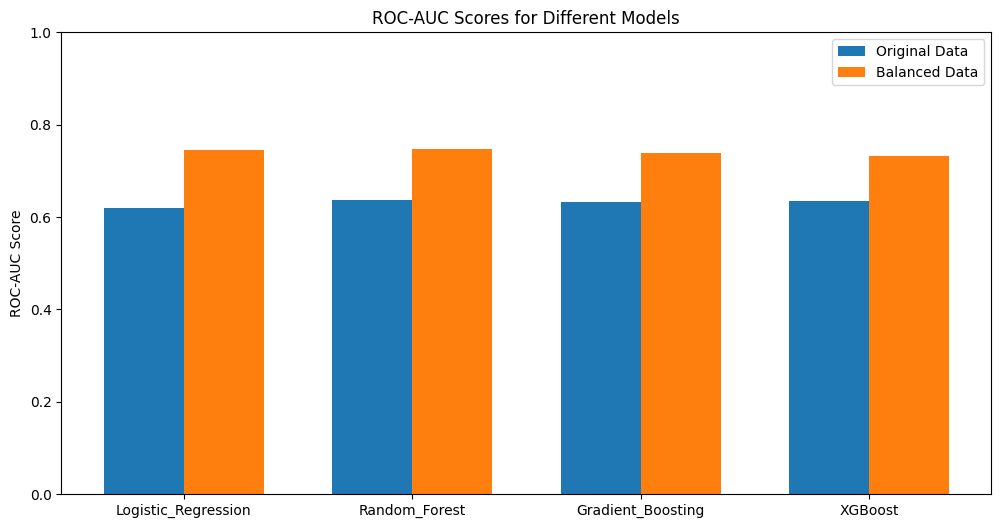

In [54]:
# Plot ROC-AUC scores for all models
model_names = list(results.keys())
roc_scores_unbalanced = [results[model]["ROC_AUC"] for model in model_names]
roc_scores_balanced = [results_balanced[model]["ROC_AUC"] for model in model_names]
x = np.arange(len(model_names))
width = 0.35
plt.figure(figsize=(12, 6))
plt.bar(x - width / 2, roc_scores_unbalanced, width, label="Original Data")
plt.bar(x + width / 2, roc_scores_balanced, width, label="Balanced Data")
plt.xticks(x, model_names)
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Scores for Different Models")
plt.legend()
plt.ylim(0, 1)
plt.show()

## 5.2 Feature Importance

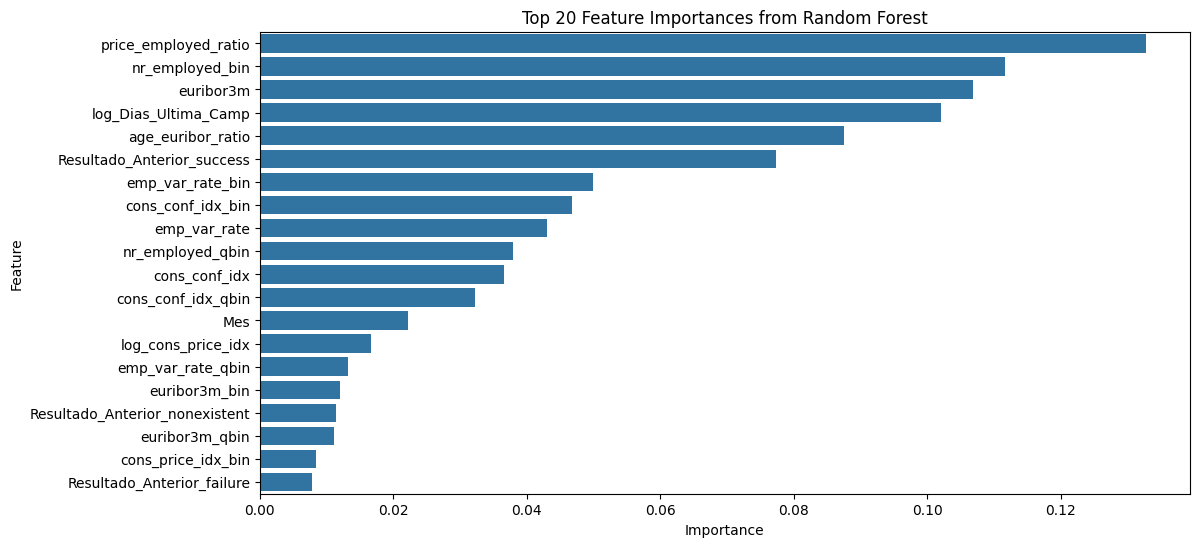

In [55]:
# Plot feature importance for the best model
if best_model == "XGBoost":
    model = xgb.XGBClassifier(
        **results_balanced[best_model]["Parameters"],
        random_state=42,
        objective="binary:logistic"
    )
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame(
        {"Feature": features, "Importance": importance}
    )
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance", ascending=False
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
    plt.title("Top 20 Feature Importances from XGBoost")
    plt.show()
elif best_model == "Random_Forest":
    model = RandomForestClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame(
        {"Feature": features, "Importance": importance}
    )
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance", ascending=False
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
    plt.title("Top 20 Feature Importances from Random Forest")
    plt.show()
elif best_model == "Gradient_Boosting":
    model = GradientBoostingClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
    model.fit(x_train, target_train)
    importance = model.feature_importances_
    features = x_train.columns
    feature_importance_df = pd.DataFrame(
        {"Feature": features, "Importance": importance}
    )
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance", ascending=False
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
    plt.title("Top 20 Feature Importances from Gradient Boosting")
    plt.show()
elif best_model == "Logistic_Regression":
    model = LogisticRegression(
        **results_balanced[best_model]["Parameters"],
        max_iter=500,
        solver="saga",
        l1_ratio=0.5,
        random_state=42
    )
    model.fit(x_train, target_train)
    importance = np.abs(model.coef_[0])
    features = x_train.columns
    feature_importance_df = pd.DataFrame(
        {"Feature": features, "Importance": importance}
    )
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance", ascending=False
    )
    plt.figure(figsize=(12, 6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(20))
    plt.title("Top 20 Feature Importances from Logistic Regression")
    plt.show()

## 5.3 Prediction Scores

In [56]:
# Predict best model
if best_model == "XGBoost":
    final_model = xgb.XGBClassifier(
        **results_balanced[best_model]["Parameters"],
        random_state=42,
        objective="binary:logistic",
    )
elif best_model == "Random_Forest":
    final_model = RandomForestClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
elif best_model == "Gradient_Boosting":
    final_model = GradientBoostingClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
elif best_model == "Logistic_Regression":
    final_model = LogisticRegression(
        **results_balanced[best_model]["Parameters"],
        max_iter=500,
        solver="saga",
        l1_ratio=0.5,
        random_state=42,
    )
final_model.fit(x_train_balanced, target_train_balanced)
test_predictions = final_model.predict(x_val)
print(
    f"Final model predictions on validation set:\n {classification_report(target_val, test_predictions)}"
)

Final model predictions on validation set:
               precision    recall  f1-score   support

           0       0.95      0.89      0.92      7019
           1       0.41      0.60      0.49       893

    accuracy                           0.86      7912
   macro avg       0.68      0.75      0.70      7912
weighted avg       0.89      0.86      0.87      7912



# 6. Train Whole Model

In [57]:
best_model = (
    "Logistic_Regression"  # Replace with the actual best model based on results
)
if best_model == "XGBoost":
    final_model = xgb.XGBClassifier(
        **results_balanced[best_model]["Parameters"],
        random_state=42,
        objective="binary:logistic",
    )
elif best_model == "Random_Forest":
    final_model = RandomForestClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
elif best_model == "Gradient_Boosting":
    final_model = GradientBoostingClassifier(
        **results_balanced[best_model]["Parameters"], random_state=42
    )
elif best_model == "Logistic_Regression":
    final_model = LogisticRegression(
        **results_balanced[best_model]["Parameters"],
        max_iter=500,
        solver="saga",
        l1_ratio=0.5,
        random_state=42,
    )


x = new_df.drop(columns=["y"])
y = new_df["y"]
x_balanced, y_balanced = x_smote.fit_resample(x, y)
print(
    f"Shape of balanced training set for final model: {x_balanced.shape}, Shape of balanced target for final model: {y_balanced.shape}"
)
final_model.fit(x_balanced, y_balanced)
final_model_filename = "final_model.pickle"
with open(final_model_filename, "wb") as file:
    pickle.dump(final_model, file)

print(f"Final model saved as {final_model_filename}")

Shape of balanced training set for final model: (40941, 34), Shape of balanced target for final model: (40941,)
Final model saved as final_model.pickle


In [58]:
new_df_test = one_hot_encode(df_test)
new_df_test = new_vars(df_test, new_df_test)
new_df_test = adjust_mes(df_test, new_df_test)
new_df_test = adjust_dias(df_test, new_df_test)
new_df_test = adjust_skewness(df_test, new_df_test)
new_df_test = bin_data(df_test, new_df_test)
final_cols_test = [col for col in final_cols if col in new_df_test.columns]
new_df_test = new_df_test[final_cols_test]
new_df_test = scaler(new_df_test, final_cols_test)
print(f"Shape of test dataframe after feature engineering: {new_df_test.shape}")
test_predictions = final_model.predict(new_df_test)
new_submission = pd.DataFrame({"ID": df_test["ID"], "y": test_predictions})
new_submission.to_csv("final_submission.csv", index=False)

Shape of new dataframe after adding numerical columns and new variables: (6594, 47)
Shape of test dataframe after feature engineering: (6594, 34)
